In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

---

# Limpieza de Datos

## Ejercicio 1

In [2]:
df_datos_en_bruto = pd.read_csv("./usu_individual_T325.txt", sep=";", low_memory=False)
df_datos_en_bruto.head()

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,8,0,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
1,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,9,0,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
2,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,1,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
3,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,2,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
4,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,3,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0


## Ejercicio 2

In [3]:
df_datos = df_datos_en_bruto[df_datos_en_bruto["H15"] == 1]

print("Eliminación de Individuos que no Completaron Encuesta")

print(f"Datos Originales: {len(df_datos_en_bruto)}")
print(f"Datos Incompletos: {len(df_datos_en_bruto) - len(df_datos)}")
print(f"Datos Restantes: {len(df_datos)}")

df_datos.head()

Eliminación de Individuos que no Completaron Encuesta
Datos Originales: 44946
Datos Incompletos: 4947
Datos Restantes: 39999


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
2,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,1,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
3,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,2,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
4,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,3,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
5,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,4,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
6,TQRMNOQSSHKLKRCDEIHJF00868831,2025,3,1,1,1,44,N,31,140,...,0,0,0,0,3.0,2.0,NaN,4.0,4.0,2.0


## Ejercicio 3

In [4]:
columnas_a_mantener = [
    "REGION",   "MAS_500", "CH04",     "CH03",     "CH06",   "CH07",       "CH09",     "CH10",
    "NIVEL_ED", "ESTADO",  "CAT_OCUP", "CAT_INAC", "SECTOR", "PP02B",      "PP02C1",   "PP02C2",
    "PP02C3",   "PP02C4",  "PP02C5",   "PP02C6",   "PP02C7", "PP02C8",     "PP02D",    "PP02F",
    "PP02G",    "PP02H",   "PP02I",    "PP03C",    "PP03D",  "PP3E_TOT",   "PP3F_TOT", "PP03G",
    "PP03H",    "PP04A",   "PP04A1",   "PP04B1",   "PP04B2", "PP04B3_ANO", "PP04C",    "PP03I",
    "PP03J",    "PP03K",   "INTENSI",  "PP04G",    "P47T"
]
df_datos = df_datos[columnas_a_mantener]
df_datos.head()

,REGION,MAS_500,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,ESTADO,...,PP04B1,PP04B2,PP04B3_ANO,PP04C,PP03I,PP03J,PP03K,INTENSI,PP04G,P47T
2,42,S,2,1,38,1,1,2,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,552000.0
3,42,S,1,2,39,1,1,2,4,1,...,2.0,0.0,0.0,1.0,2.0,2.0,0.0,2.0,8.0,400000.0
4,42,S,1,3,18,5,1,1,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,42,S,1,3,17,5,1,2,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
6,44,N,1,1,50,2,1,2,3,1,...,2.0,0.0,0.0,10.0,2.0,2.0,0.0,2.0,11.0,1200000.0


## Ejercicio 4

In [5]:
columnas_con_faltantes = [
    "PP03C", "PP03D",  "PP3E_TOT", "PP3F_TOT",
    "PP03G", "PP03H",  "PP03I",    "PP03J",
    "PP03K", "PP04B1", "PP04B2",   "PP04B3_ANO",
    "PP04C", "PP04A",  "PP04A1",   "PP04G",
    "INTENSI" 
]

print("Eliminación de NA")
print(f"Antes:   {df_datos[columnas_con_faltantes].isna().sum().sum()} NA")
df_datos = df_datos.fillna({ columna: 0 for columna in columnas_con_faltantes })
print(f"Después: {df_datos[columnas_con_faltantes].isna().sum().sum()} NA")

df_datos.head()

Eliminación de NA
Antes:   338861 NA
Después: 0 NA


,REGION,MAS_500,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,ESTADO,...,PP04B1,PP04B2,PP04B3_ANO,PP04C,PP03I,PP03J,PP03K,INTENSI,PP04G,P47T
2,42,S,2,1,38,1,1,2,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,552000.0
3,42,S,1,2,39,1,1,2,4,1,...,2.0,0.0,0.0,1.0,2.0,2.0,0.0,2.0,8.0,400000.0
4,42,S,1,3,18,5,1,1,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,42,S,1,3,17,5,1,2,3,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,44,N,1,1,50,2,1,2,3,1,...,2.0,0.0,0.0,10.0,2.0,2.0,0.0,2.0,11.0,1200000.0


## Ejercicio 5

In [6]:
print("Eliminación de Filas Sin Ingresos Totales")
print(f"Antes:   {len(df_datos)}")

df_datos = df_datos[df_datos["P47T"] > 0]

print(f"Después: {len(df_datos)}")

df_datos.head()

Eliminación de Filas Sin Ingresos Totales
Antes:   39999
Después: 23674


,REGION,MAS_500,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,ESTADO,...,PP04B1,PP04B2,PP04B3_ANO,PP04C,PP03I,PP03J,PP03K,INTENSI,PP04G,P47T
2,42,S,2,1,38,1,1,2,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,552000.0
3,42,S,1,2,39,1,1,2,4,1,...,2.0,0.0,0.0,1.0,2.0,2.0,0.0,2.0,8.0,400000.0
6,44,N,1,1,50,2,1,2,3,1,...,2.0,0.0,0.0,10.0,2.0,2.0,0.0,2.0,11.0,1200000.0
10,44,N,2,1,74,2,1,2,4,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000000.0
11,44,N,1,2,71,2,1,2,2,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1200000.0


## Ejercicio 6

In [7]:
print("Eliminación de Filas con Faltantes")
print(f"Antes:   {len(df_datos)}")

df_datos = df_datos.dropna()

print(f"Después: {len(df_datos)}")

Eliminación de Filas con Faltantes
Antes:   23674
Después: 15542


## Ejercicio 7

In [8]:
columnas_a_convertir_a_dummy = [
    "ESTADO", "REGION", "MAS_500", "CAT_OCUP", "CAT_INAC", "PP02B",    "PP02C1",   "PP02C2",
    "PP02C3", "PP02C4", "PP02C5",  "PP02C6",   "PP02C7",   "PP02C8",   "PP02D",    "PP02F",
    "PP02G",  "PP02H",  "PP02I",   "PP03C",    "PP03D",    "PP3E_TOT", "PP3F_TOT", "PP03G",
    "PP03H",  "PP03I",  "PP03J",   "PP03K",    "INTENSI",  "PP04A",    "PP04A1",   "PP04G"
]

df_datos = pd.merge(
    df_datos[df_datos.columns.difference(columnas_a_convertir_a_dummy)],
    pd.get_dummies(df_datos, columns=columnas_a_convertir_a_dummy)
)

df_datos.head()

,CH03,CH04,CH06,CH07,CH09,CH10,NIVEL_ED,P47T,PP04B1,PP04B2,...,PP04G_4.0,PP04G_5.0,PP04G_6.0,PP04G_7.0,PP04G_8.0,PP04G_9.0,PP04G_10.0,PP04G_11.0,PP04G_12.0,PP04G_13.0
0,2,1,39,1,1,2,4,400000.0,2.0,0.0,...,False,False,False,False,True,False,False,False,False,False
1,2,1,39,1,1,2,4,400000.0,2.0,0.0,...,False,False,False,False,False,False,False,True,False,False
2,1,1,50,2,1,2,3,1200000.0,2.0,0.0,...,False,False,False,False,False,False,False,True,False,False
3,5,1,29,5,1,2,4,500000.0,2.0,0.0,...,False,False,False,False,False,False,False,True,False,False
4,1,1,32,3,1,2,4,930000.0,2.0,0.0,...,False,False,False,False,False,True,False,False,False,False


## Ejercicio 8

In [9]:
df_clean = df_datos.copy()

df_clean["CH07"] = np.where(df_clean["CH07"] == 5, True, False)
df_clean["CH09"] = np.where(df_clean["CH09"] == 1, True, False)

df_clean["NIVEL_ED"] = df_clean["NIVEL_ED"].replace(7, 0)

df_clean[["CH07", "CH09", "NIVEL_ED"]]

,CH07,CH09,NIVEL_ED
0,False,True,4
1,False,True,4
2,False,True,3
3,True,True,4
4,False,True,4
...,...,...,...
15879,True,True,4
15880,False,True,4
15881,False,True,6
15882,False,True,6


# Clustering

## Ejercicio 9

In [10]:
df_clustering = pd.merge(
    df_clean[df_clean.columns.difference(["SECTOR"])],
    pd.get_dummies(df_clean, columns=["SECTOR"])
)

df_clustering.head()

,CAT_INAC_0,CAT_OCUP_1,CAT_OCUP_2,CAT_OCUP_3,CAT_OCUP_4,CH03,CH04,CH06,CH07,CH09,...,REGION_1,REGION_40,REGION_41,REGION_42,REGION_43,REGION_44,SECTOR_1.0,SECTOR_2.0,SECTOR_3.0,SECTOR_9.0
0,True,False,True,False,False,2,1,39,False,True,...,False,False,False,True,False,False,False,True,False,False
1,True,False,True,False,False,2,1,39,False,True,...,False,False,False,True,False,False,False,True,False,False
2,True,False,True,False,False,2,1,39,False,True,...,False,False,False,False,True,False,False,True,False,False
3,True,False,True,False,False,2,1,39,False,True,...,False,False,False,False,True,False,False,True,False,False
4,True,False,False,True,False,1,1,50,False,True,...,False,False,False,False,False,True,True,False,False,False


## Ejercicio 10

In [146]:
scaler = StandardScaler().set_output(transform="pandas")

df_clustering_escalado = scaler.fit_transform(df_clustering)
pca = PCA(n_components=2)
componentes_principales = pca.fit_transform(df_clustering_escalado)

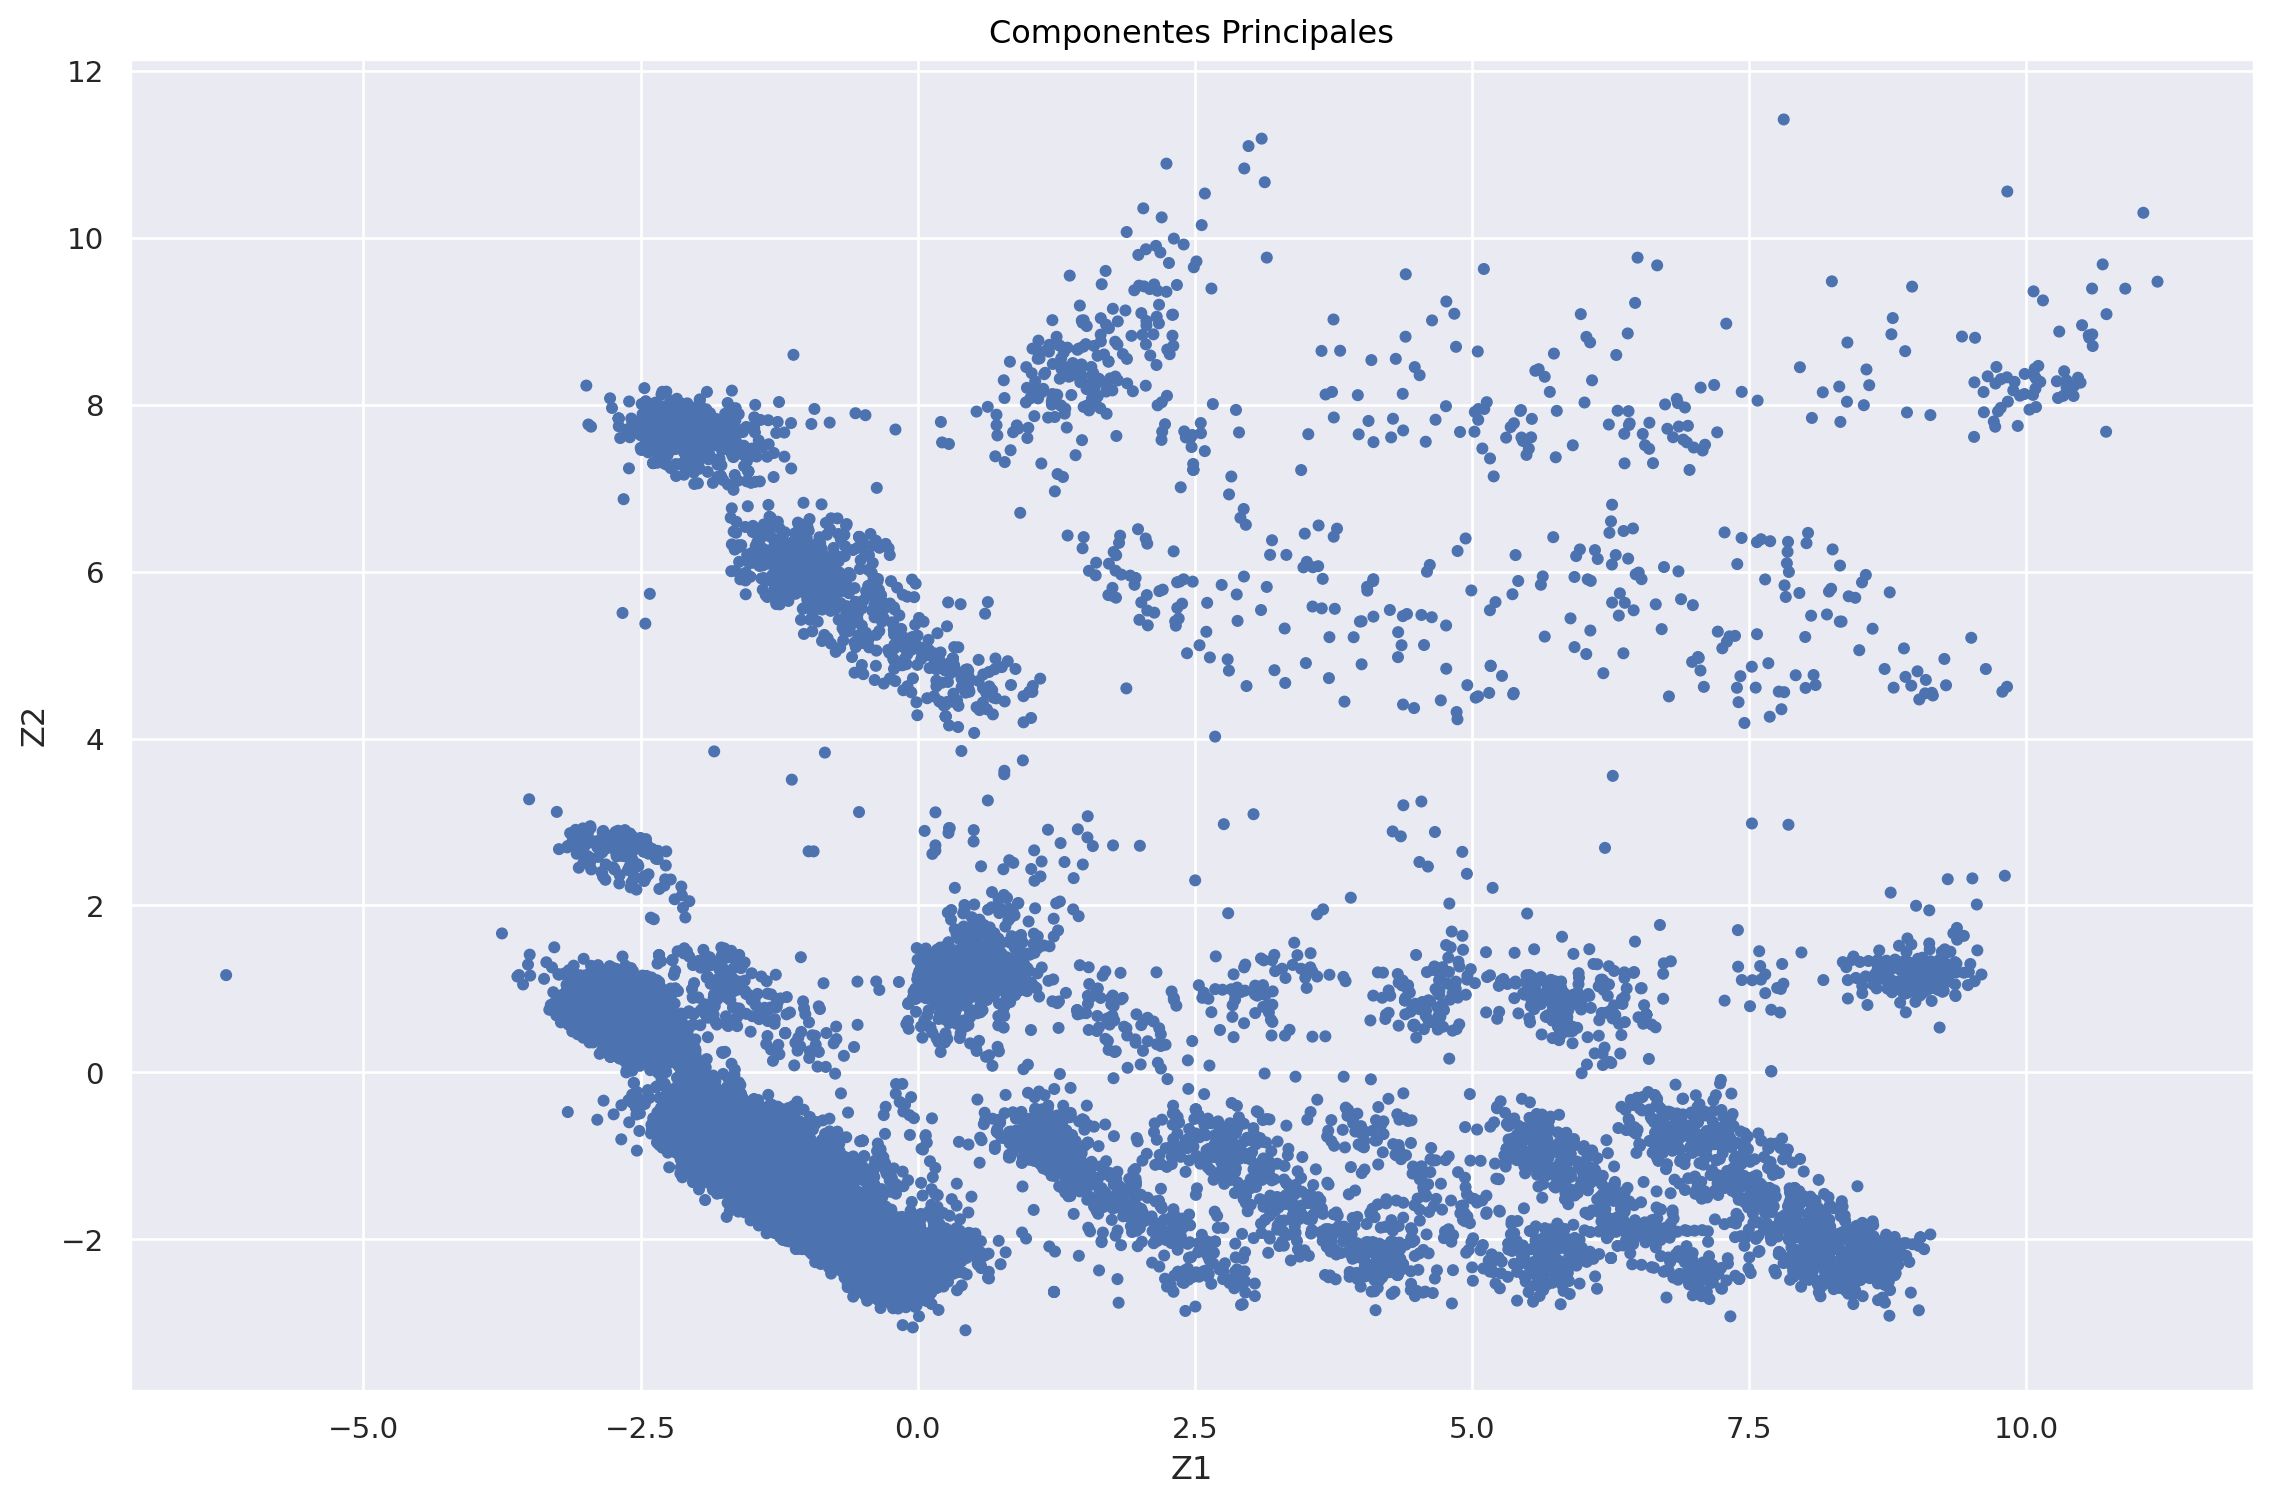

In [12]:
(
    so.Plot(
        x=componentes_principales[:, 0],
        y=componentes_principales[:, 1]
    )
    .add(so.Dot(pointsize=4))
    .label(x="Z1", y="Z2")
    .layout(size=(12, 8))
    .label(title="Componentes Principales")
)

A simple vista se pueden considerar dos regiones generales, dadas por una línea imaginaria en Z2 = 4

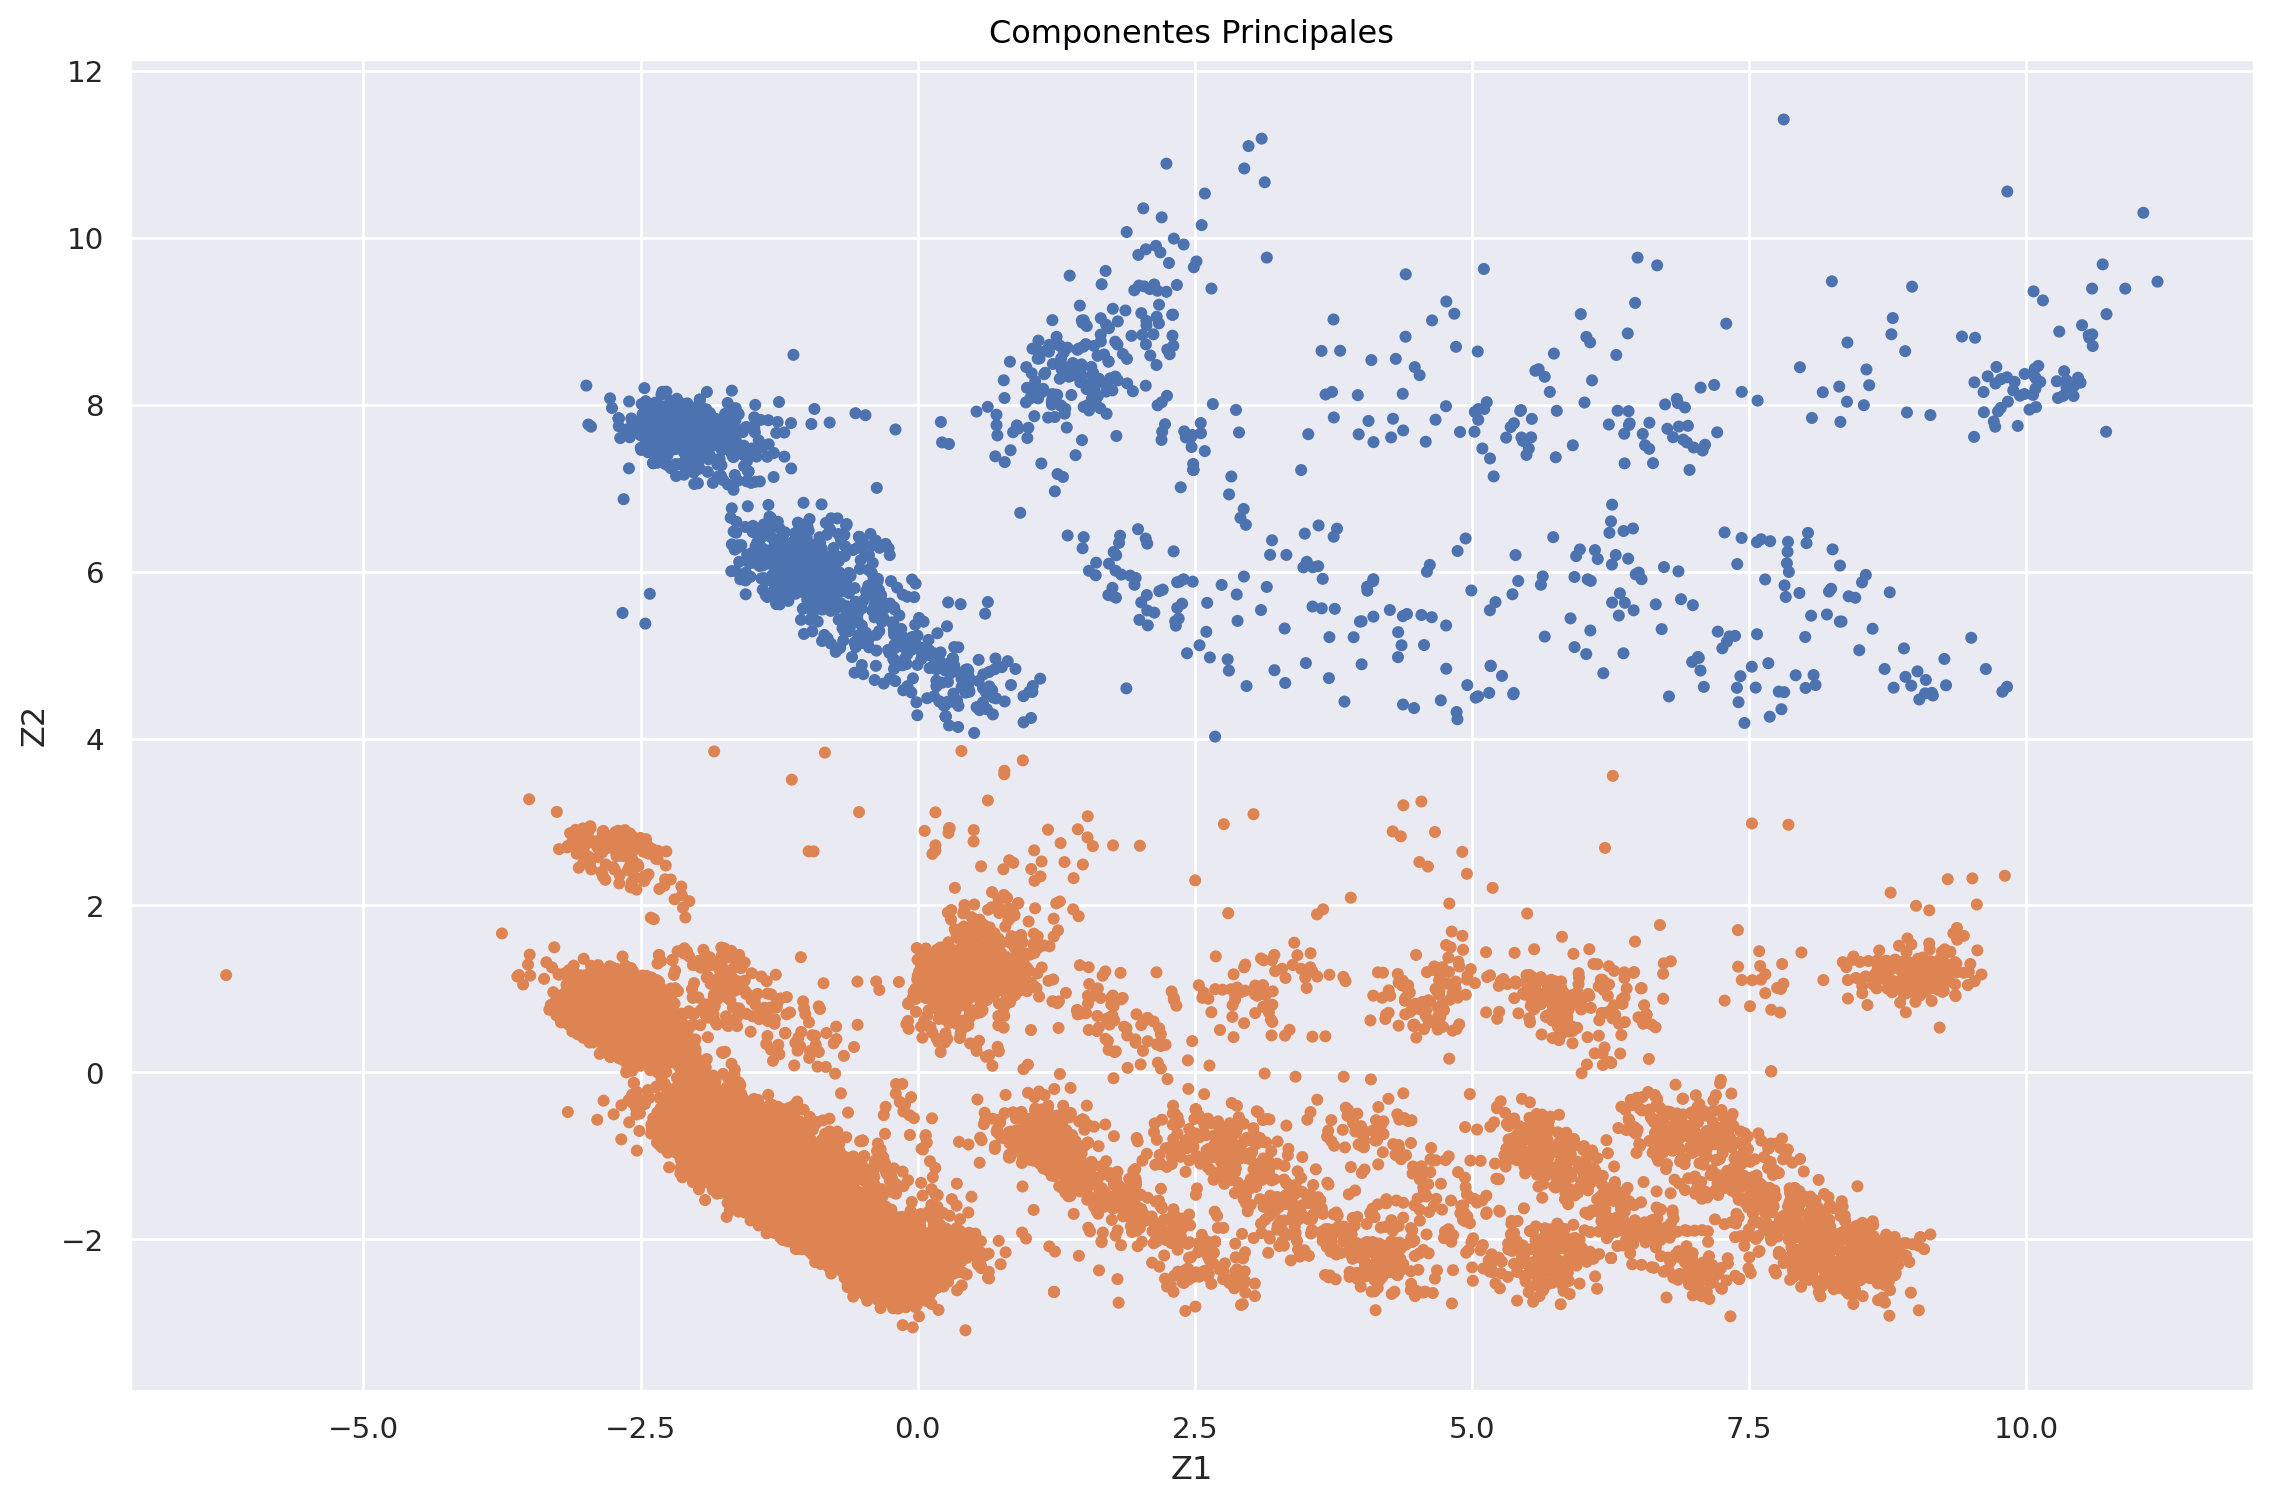

In [13]:
(
    so.Plot(
        x=componentes_principales[:, 0],
        y=componentes_principales[:, 1],
        color=componentes_principales[:, 1] >= 4
    )
    .add(so.Dot(pointsize=4), legend=None)
    .label(x="Z1", y="Z2")
    .layout(size=(12, 8))
    .label(title="Componentes Principales")
)

## Ejercicio 11

Para este ejercicio se utilizará el algoritmo de K-Means. Además, para la estimación del hiperparámetro óptimo se hará uso del método del codo.

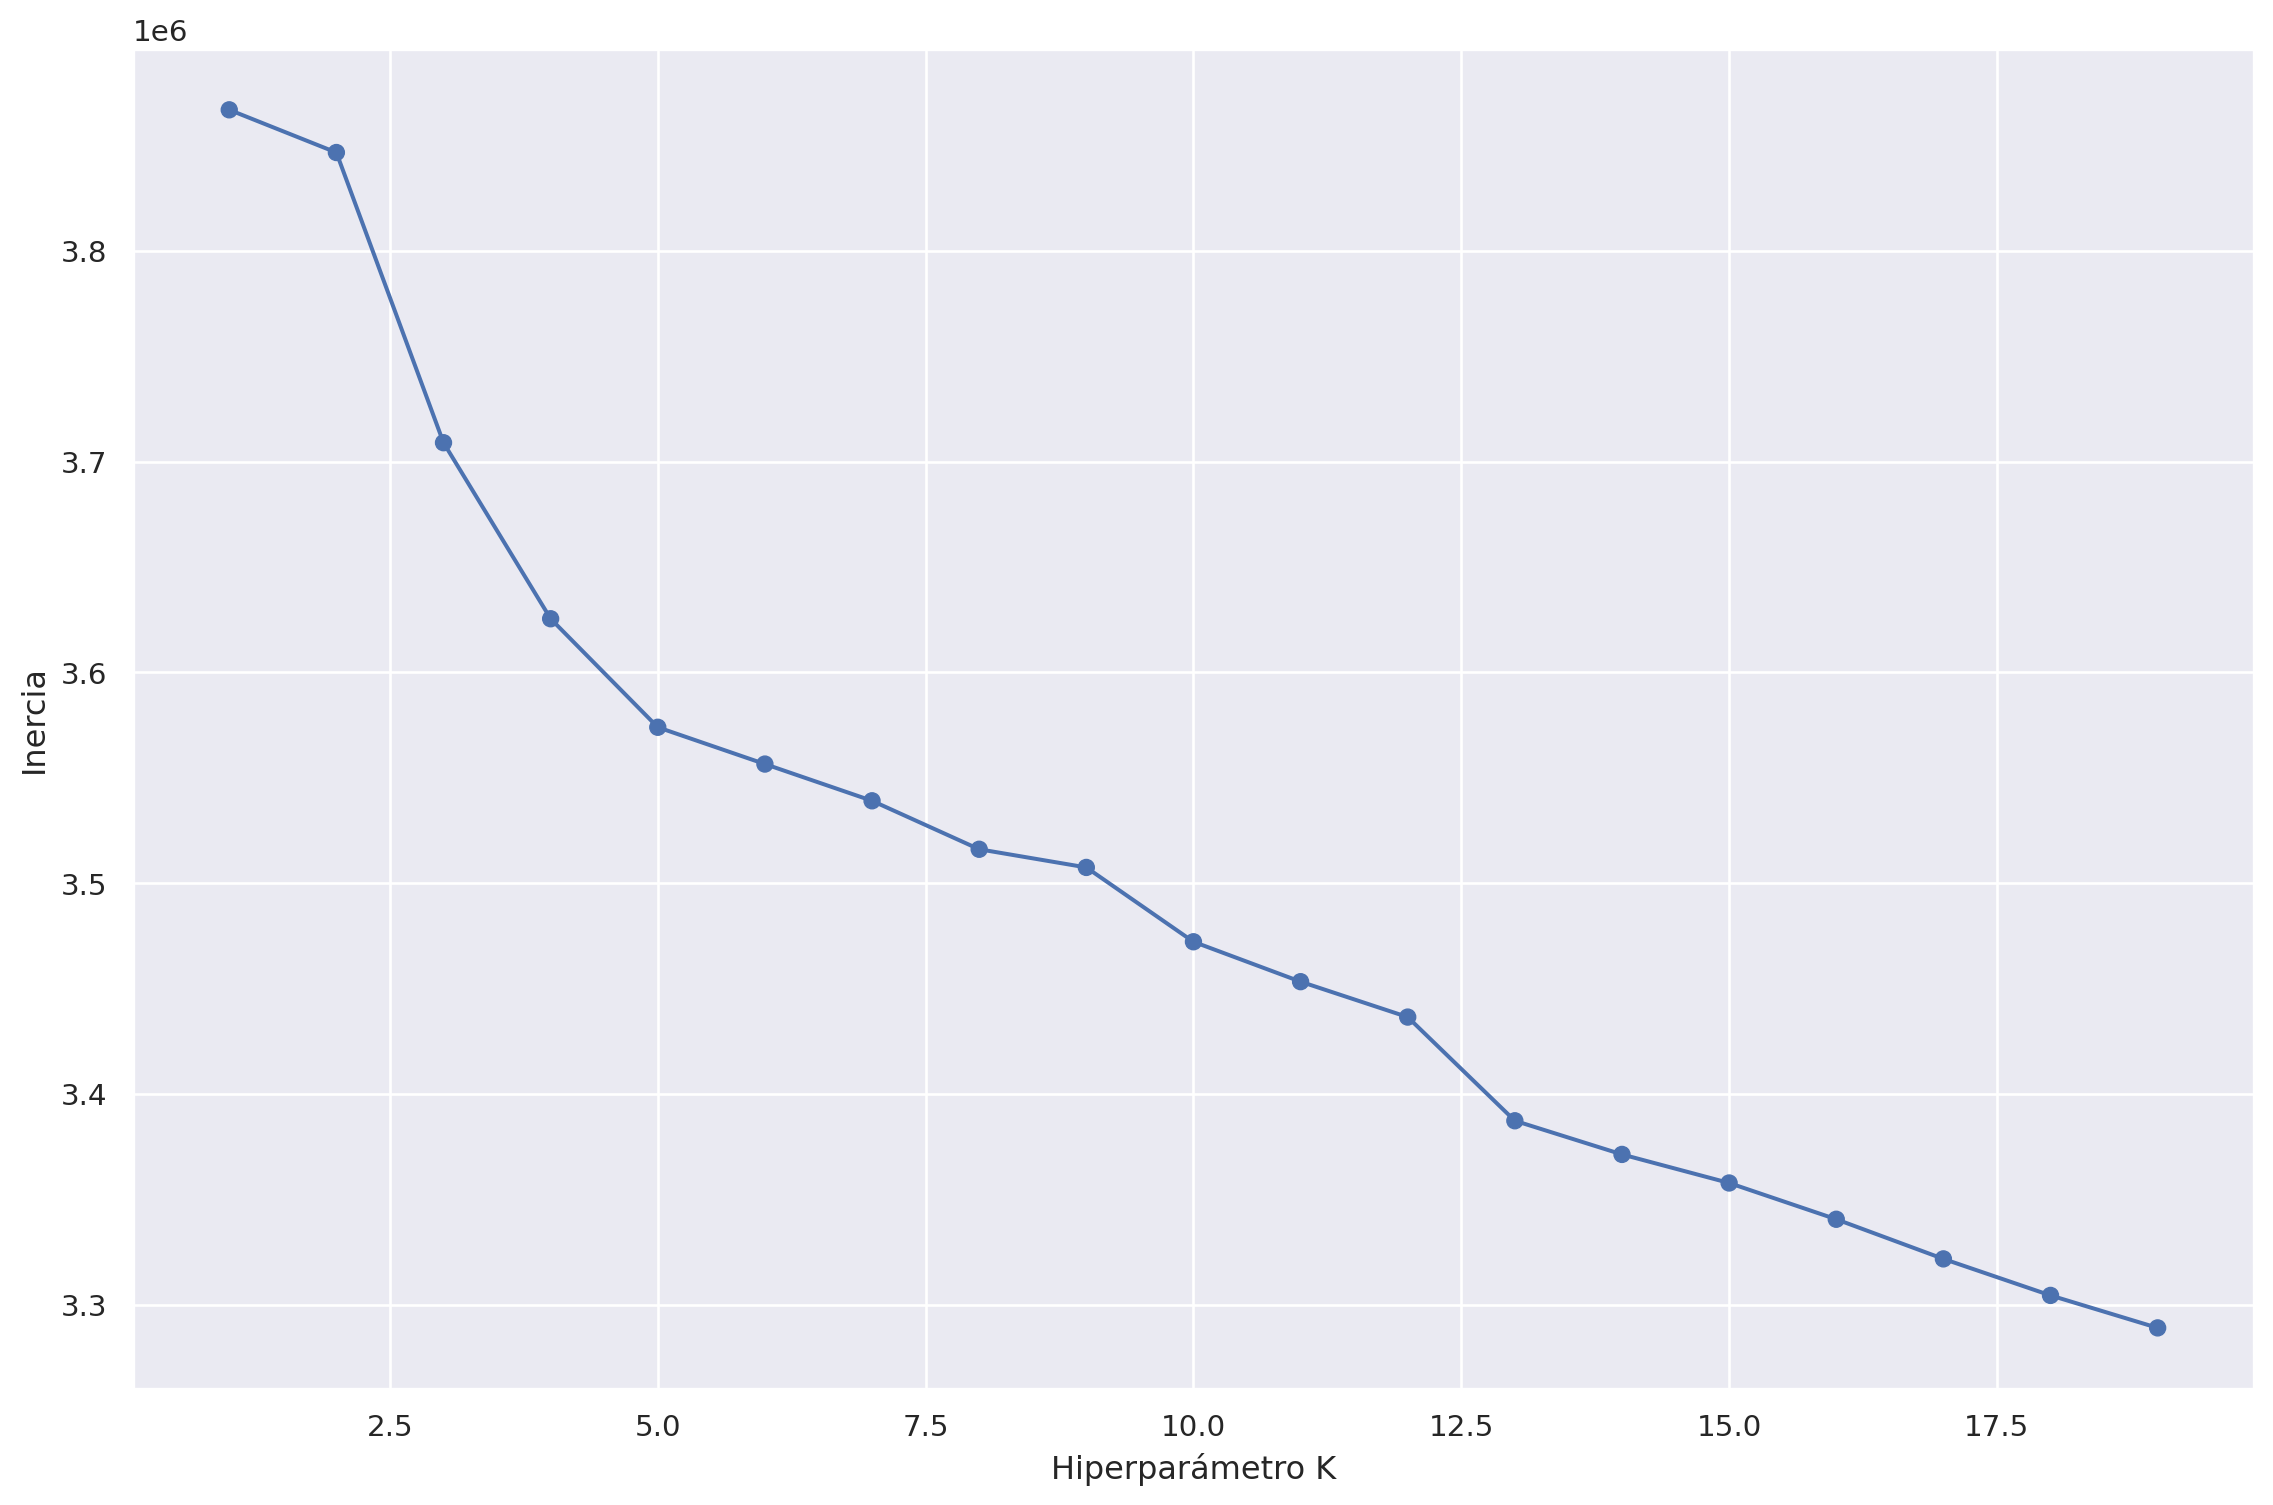

In [51]:
metricas = []
for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(df_clustering_escalado)
    
    metricas.append([k, kmeans.inertia_])

metricas = pd.DataFrame(metricas, columns=["k", "inercia"])

(
    so.Plot(data=metricas, x="k", y="inercia")
    .add(so.Line())
    .add(so.Dot())
    .layout(size=(12, 8))
    .label(x="Hiperparámetro K", y="Inercia")
)

## Ejercicio 12

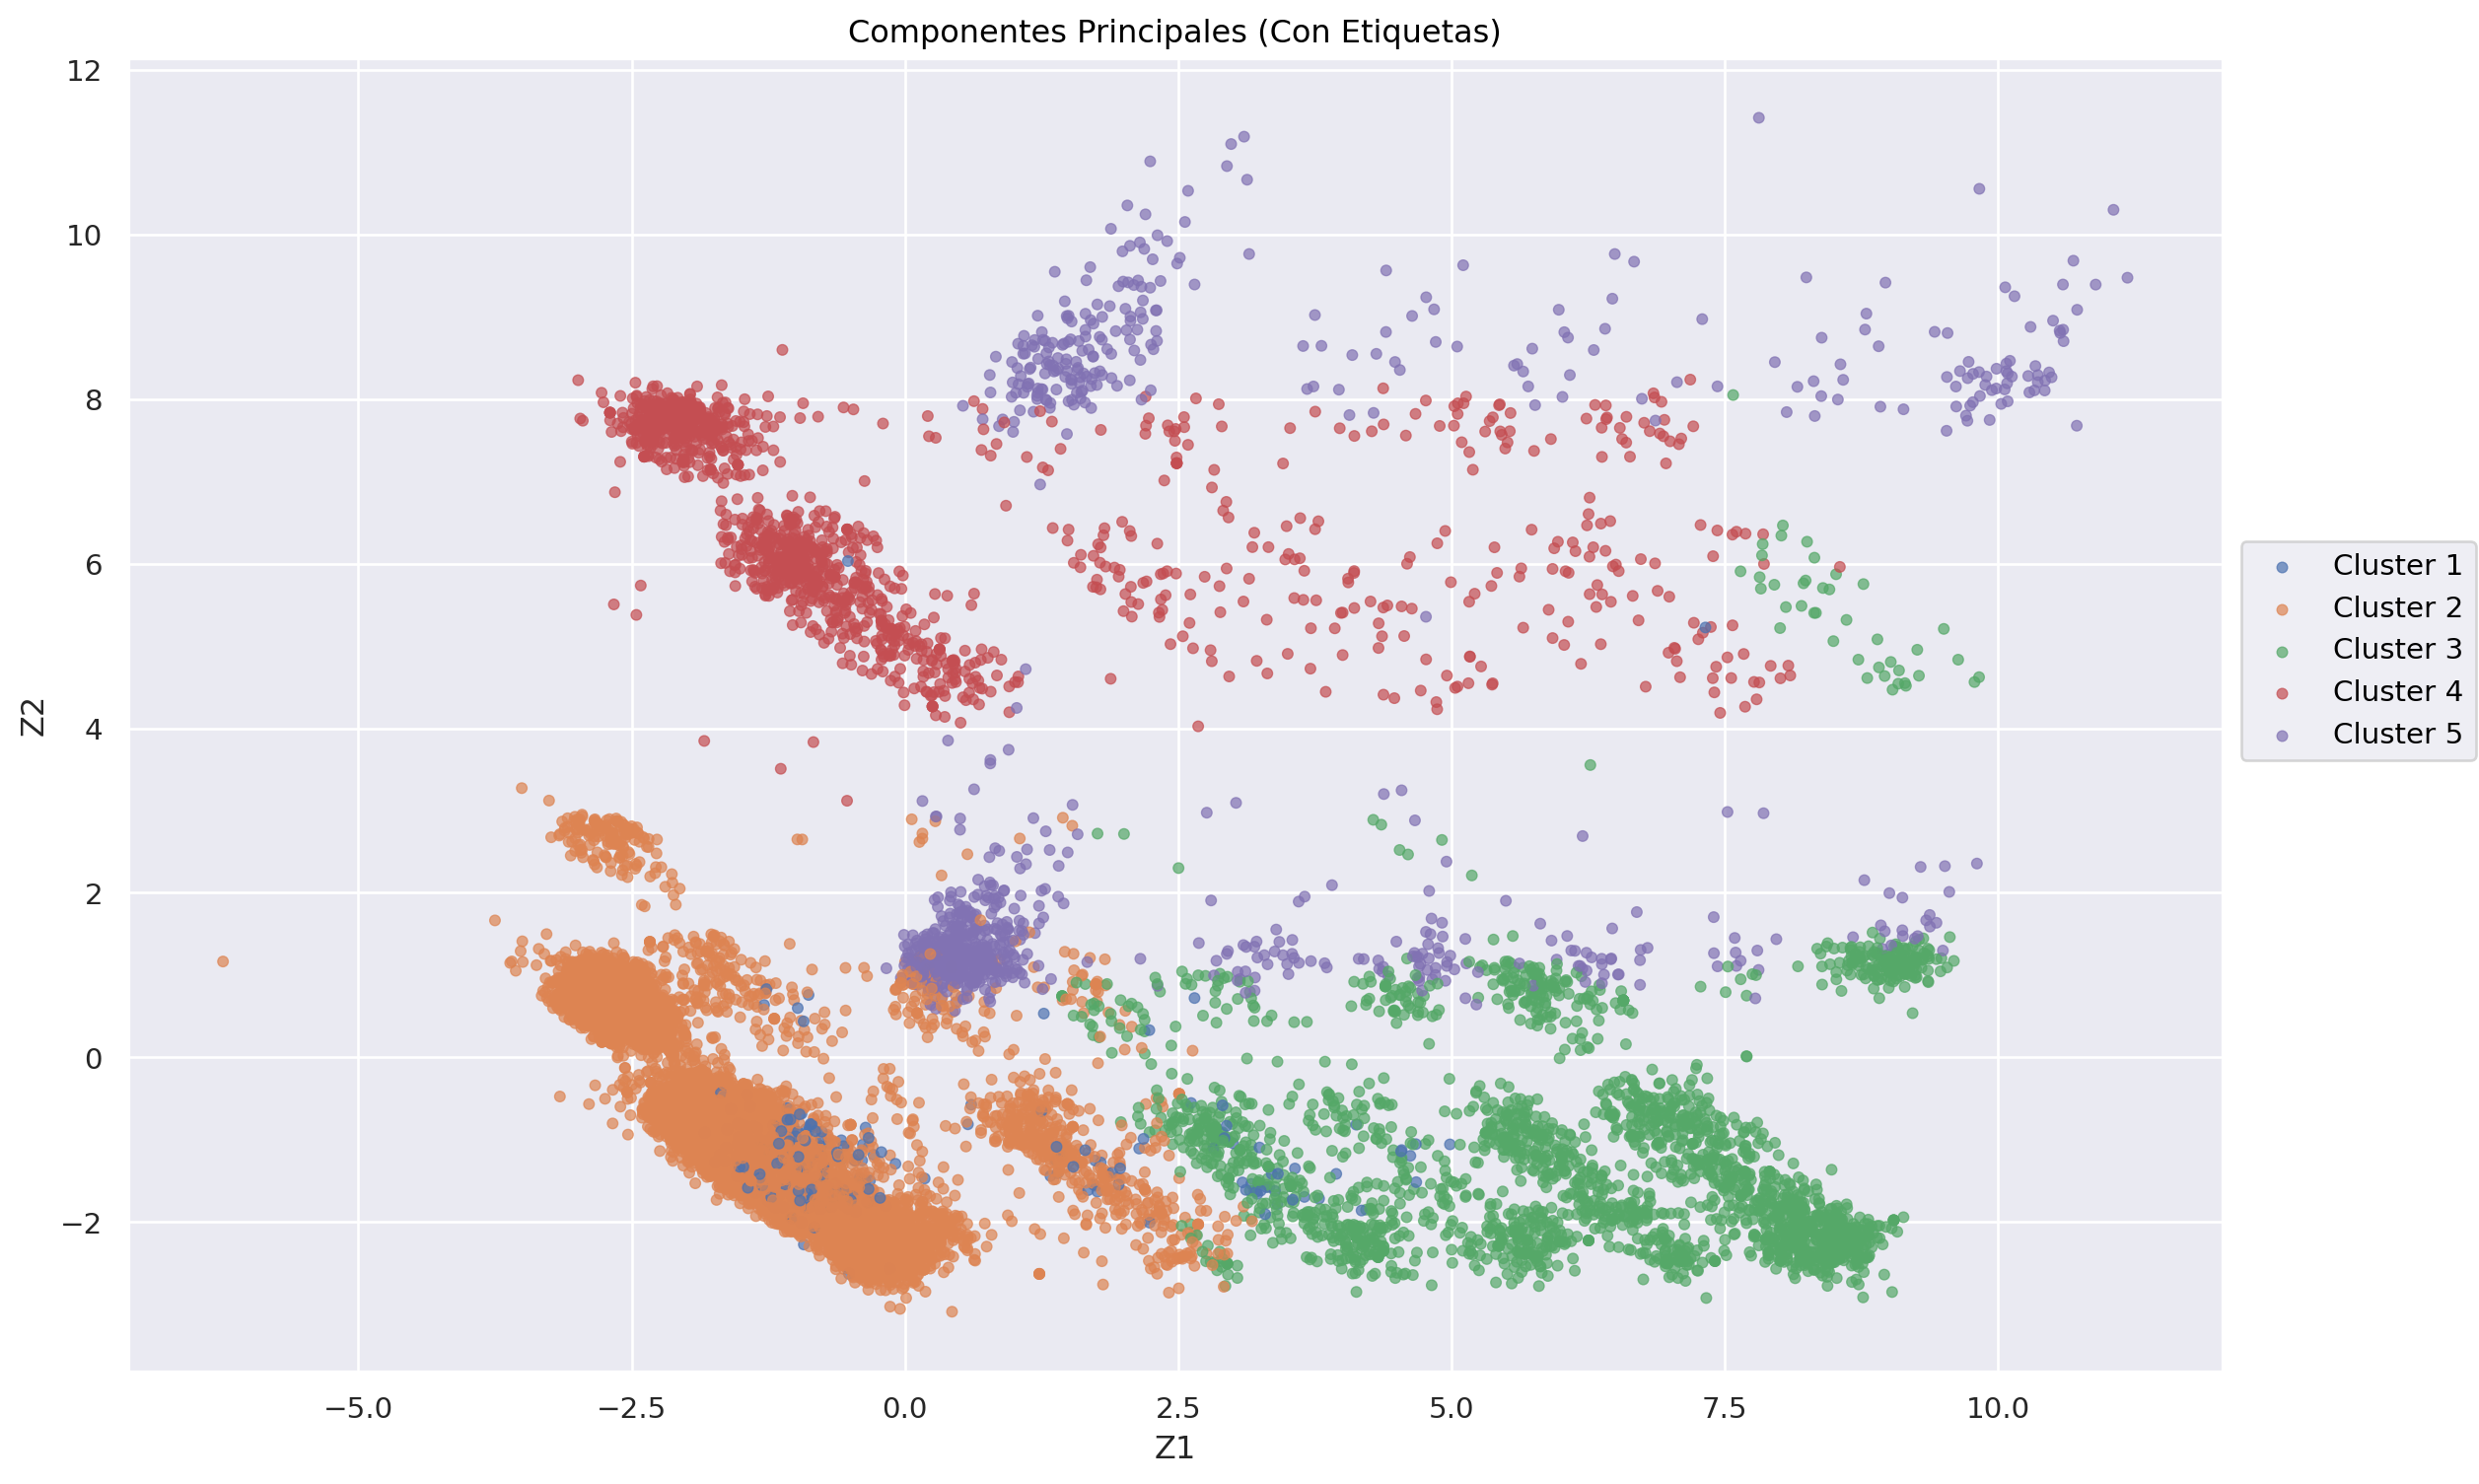

In [210]:
clustering = KMeans(n_clusters=5, random_state=0)
clustering.fit(df_clustering_escalado)
etiquetas = np.array([f"Cluster {nombre + 1}" for nombre in clustering.labels_])

(
    so.Plot(
        x=componentes_principales[:, 0],
        y=componentes_principales[:, 1],
        color=etiquetas
    )
    .add(so.Dot(alpha=0.7, pointsize=4))
    .label(x="Z1", y="Z2")
    .layout(size=(12, 8))
    .scale(color=so.Nominal(order=np.unique(etiquetas)))
    .label(title="Componentes Principales (Con Etiquetas)")
)

In [211]:
df_clustering[etiquetas == "Cluster 2"]

,CAT_INAC_0,CAT_OCUP_1,CAT_OCUP_2,CAT_OCUP_3,CAT_OCUP_4,CH03,CH04,CH06,CH07,CH09,...,REGION_1,REGION_40,REGION_41,REGION_42,REGION_43,REGION_44,SECTOR_1.0,SECTOR_2.0,SECTOR_3.0,SECTOR_9.0
2,True,False,True,False,False,2,1,39,False,True,...,False,False,False,False,True,False,False,True,False,False
3,True,False,True,False,False,2,1,39,False,True,...,False,False,False,False,True,False,False,True,False,False
4,True,False,False,True,False,1,1,50,False,True,...,False,False,False,False,False,True,True,False,False,False
5,True,False,False,True,False,5,1,29,True,True,...,False,False,False,False,False,True,True,False,False,False
9,True,False,False,True,False,1,1,50,False,True,...,False,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16805,True,False,False,True,False,1,1,50,False,True,...,False,True,False,False,False,False,True,False,False,False
16806,True,False,False,True,False,2,2,53,False,True,...,False,True,False,False,False,False,True,False,False,False
16807,True,False,False,True,False,3,1,30,True,True,...,False,True,False,False,False,False,True,False,False,False
16808,True,False,False,True,False,2,2,43,False,True,...,False,True,False,False,False,False,True,False,False,False


In [212]:
reescalado = pd.DataFrame(
    data=scaler.inverse_transform(clustering.cluster_centers_),
    index=np.unique(etiquetas),
    columns=df_clustering.columns
).round()
reescalado

,CAT_INAC_0,CAT_OCUP_1,CAT_OCUP_2,CAT_OCUP_3,CAT_OCUP_4,CH03,CH04,CH06,CH07,CH09,...,REGION_1,REGION_40,REGION_41,REGION_42,REGION_43,REGION_44,SECTOR_1.0,SECTOR_2.0,SECTOR_3.0,SECTOR_9.0
Cluster 1,1.0,0.0,0.0,1.0,0.0,2.0,1.0,36.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Cluster 2,1.0,0.0,0.0,1.0,0.0,2.0,1.0,41.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Cluster 3,1.0,0.0,0.0,1.0,0.0,2.0,1.0,38.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cluster 4,1.0,0.0,0.0,1.0,0.0,2.0,2.0,42.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Cluster 5,1.0,0.0,-0.0,1.0,0.0,2.0,2.0,44.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,1.0,0.0


In [213]:
pd.DataFrame(scaler.inverse_transform(relevancia), index=relevancia.index, columns=relevancia.columns).round()

,CAT_INAC_0,CAT_OCUP_1,CAT_OCUP_2,CAT_OCUP_3,CAT_OCUP_4,CH03,CH04,CH06,CH07,CH09,...,REGION_1,REGION_40,REGION_41,REGION_42,REGION_43,REGION_44,SECTOR_1.0,SECTOR_2.0,SECTOR_3.0,SECTOR_9.0
Cluster 0,1.0,0.0,0.0,1.0,0.0,2.0,1.0,36.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Cluster 1,1.0,0.0,0.0,1.0,0.0,2.0,1.0,41.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Cluster 2,1.0,0.0,0.0,1.0,0.0,2.0,1.0,38.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cluster 3,1.0,0.0,0.0,1.0,0.0,2.0,2.0,42.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Cluster 4,1.0,0.0,-0.0,1.0,0.0,2.0,2.0,44.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,1.0,0.0


In [226]:
datos = df_clustering.copy()
datos["cluster"] = etiquetas

(
    datos
    .groupby("cluster")[datos.columns.drop("cluster")]
    .agg(["mean", "median", "std"])
)

clusters = pd.DataFrame(clustering.cluster_centers_, columns=df_clustering.columns)
for i in range(len(clusters)):
    top = (
        clusters
        .iloc[i]
        .abs()
        .sort_values(ascending=False)
    )
    print(top)

SECTOR_9.0       5.792886
SECTOR_1.0       1.439542
PP3E_TOT_91.0    0.653009
PP04C            0.617660
CAT_OCUP_3       0.550944
                   ...   
PP02C2_0         0.000000
PP02C6_0         0.000000
PP02C7_0         0.000000
PP02C8_0         0.000000
PP02D_0          0.000000
Name: 0, Length: 246, dtype: float64
PP03H_0.0    0.419996
PP03G_1.0    0.419996
PP03G_2.0    0.419869
PP03H_1.0    0.416410
PP03I_2.0    0.411861
               ...   
PP02C2_0     0.000000
PP02C6_0     0.000000
PP02C7_0     0.000000
PP02C8_0     0.000000
PP02D_0      0.000000
Name: 1, Length: 246, dtype: float64
PP03G_1.0    2.059816
PP03H_0.0    2.059816
PP03G_2.0    2.059371
PP03H_1.0    2.057843
PP03I_1.0    2.027448
               ...   
PP02C2_0     0.000000
PP02C6_0     0.000000
PP02C7_0     0.000000
PP02C8_0     0.000000
PP02D_0      0.000000
Name: 2, Length: 246, dtype: float64
PP03D_0.0       3.048797
PP03C_2.0       3.048797
PP3F_TOT_0.0    3.036795
PP03D_2.0       2.912363
PP03C_1.0       2.7

In [206]:
df_clustering[etiquetas == "Cluster 2"].std().sort_values(ascending=False).head(10)

P47T          533122.730992
PP04C             22.844373
CH06              12.723983
CH03               1.506500
NIVEL_ED           1.320923
PP03K_2.0          0.499996
SECTOR_2.0         0.499618
CH04               0.498639
CAT_OCUP_3         0.497692
CAT_OCUP_2         0.495203
dtype: float64

In [97]:
informacion = []
for cluster in np.unique(etiquetas):
    datos = (
        df_clustering[etiquetas == cluster]
        .select_dtypes(include=["bool"])
        .astype(int)
        .describe()
    )

    informacion.append([cluster, datos.columns[datos.iloc[2] != 0]])

informacion

[[np.str_('Cluster 0'),
  Index(['CAT_OCUP_2', 'CAT_OCUP_3', 'CAT_OCUP_4', 'CH07', 'CH09', 'INTENSI_1.0',
         'INTENSI_2.0', 'INTENSI_3.0', 'INTENSI_4.0', 'MAS_500_N',
         ...
         'PP3F_TOT_999.0', 'REGION_1', 'REGION_40', 'REGION_41', 'REGION_42',
         'REGION_43', 'REGION_44', 'SECTOR_1.0', 'SECTOR_2.0', 'SECTOR_9.0'],
        dtype='str', length=107)],
 [np.str_('Cluster 1'),
  Index(['CAT_OCUP_1', 'CAT_OCUP_2', 'CAT_OCUP_3', 'CAT_OCUP_4', 'CH07', 'CH09',
         'INTENSI_1.0', 'INTENSI_2.0', 'INTENSI_3.0', 'INTENSI_4.0',
         ...
         'PP3E_TOT_999.0', 'REGION_1', 'REGION_40', 'REGION_41', 'REGION_42',
         'REGION_43', 'REGION_44', 'SECTOR_1.0', 'SECTOR_2.0', 'SECTOR_3.0'],
        dtype='str', length=155)],
 [np.str_('Cluster 2'),
  Index(['CAT_OCUP_1', 'CAT_OCUP_2', 'CAT_OCUP_3', 'CAT_OCUP_4', 'CH07', 'CH09',
         'INTENSI_1.0', 'INTENSI_2.0', 'INTENSI_3.0', 'INTENSI_4.0',
         ...
         'REGION_1', 'REGION_40', 'REGION_41', 'REGION_42'

# Clasificación

# Regresión